# Milestone 2: Artist Profiling
Liam — CSC 475, Music Maven (Group 4)

Objective 1, PI.1 / PI.3 / PI.4 / PI.5:
- PI.1: Extract per-song MIR features from the dataset (loaded from Milestone 1)
- PI.3: Normalize feature vectors and store artist profiles in structured Pandas DataFrames
- PI.4: Compare aggregation methods (mean vs median vs variance) and evaluate their impact on artist representation
- PI.5: Feature selection — identify which MIR features are most discriminative for artist classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

MIR_FEATURES = ["tempo", "energy", "valence", "danceability", "key", "mode"]

## PI.1: Load Per-Song MIR Features
Load from `songs.csv` produced by Milestone 1. If that file is not present, re-run Milestone 1 first.

In [2]:
import os

if not os.path.exists("songs.csv"):
    raise FileNotFoundError(
        "songs.csv not found — run milestone1.ipynb first to generate."
    )

songs = pd.read_csv("songs.csv")

print(f"Songs loaded: {len(songs):,}")
print(f"Unique artists: {songs['artist_id'].nunique()}")
print(f"MIR feature columns: {MIR_FEATURES}\n")
songs[MIR_FEATURES].describe().round(3)

Songs loaded: 109,251
Unique artists: 16267
MIR feature columns: ['tempo', 'energy', 'valence', 'danceability', 'key', 'mode']



,tempo,energy,valence,danceability,key,mode
count,109251.000,109251.000,109251.000,109251.000,109251.000,109251.000
mean,122.773,0.667,0.446,0.521,5.284,0.625
std,28.957,0.241,0.252,0.173,3.561,0.484
min,32.528,0.000,0.000,0.056,0.000,0.000
25%,100.212,0.502,0.236,0.403,2.000,0.000
50%,121.083,0.712,0.424,0.528,5.000,1.000
75%,140.047,0.872,0.639,0.645,9.000,1.000
max,242.903,1.000,0.998,0.988,11.000,1.000


## PI.3: Normalization + Artist Profiles

Tempo runs from roughly 60–200 BPM while energy, valence, and danceability are in [0, 1].
Key is an integer 0–11. Mode is binary (0 = minor, 1 = major).
Without normalization, tempo would dominate any distance calculation.

We support two normalization strategies:
- **Min-max**: scales each feature to [0, 1] based on the dataset range
- **Z-score**: standardizes to mean 0 / std 1 — useful when outliers are present *(ARCHIVED - ONLY USED MIN-MAX, KEPT FOR DOCUMENTATAION)*

Normalization is fitted on the full song set and the parameters are saved so the same transform can be applied to any query vector later (e.g., in Kevin's k-NN classifier).

In [3]:
def normalize_features(X, method="minmax"):
    """
    Normalize feature matrix X (n_samples x n_features).
    Returns (normalized_matrix, params_dict).
    params_dict lets us apply the same transform to new vectors later.
    """
    X = np.array(X, dtype=float)

    if method == "minmax":
        mins   = X.min(axis=0)
        maxs   = X.max(axis=0)
        ranges = maxs - mins
        with np.errstate(invalid="ignore", divide="ignore"):
            X_norm = np.where(ranges == 0, 0.0, (X - mins) / ranges)
        params = {"method": "minmax", "mins": mins, "maxs": maxs}

    elif method == "zscore":
        means = X.mean(axis=0)
        stds  = X.std(axis=0)
        with np.errstate(invalid="ignore", divide="ignore"):
            X_norm = np.where(stds == 0, 0.0, (X - means) / stds)
        params = {"method": "zscore", "means": means, "stds": stds}

    else:
        raise ValueError(f"Something went wrong...")

    return X_norm, params


def apply_normalization(x, params):
    """Apply fitted normalization params to a single query vector."""
    x = np.array(x, dtype=float)
    method = params["method"]

    if method == "minmax":
        ranges = params["maxs"] - params["mins"]
        with np.errstate(invalid="ignore", divide="ignore"):
            return np.where(ranges == 0, 0.0, (x - params["mins"]) / ranges)

    elif method == "zscore":
        with np.errstate(invalid="ignore", divide="ignore"):
            return np.where(params["stds"] == 0, 0.0, (x - params["means"]) / params["stds"])


# normalize the song-level feature matrix
raw_matrix          = songs[MIR_FEATURES].to_numpy(dtype=float)
norm_matrix_minmax, norm_params_minmax = normalize_features(raw_matrix, method="minmax")
norm_matrix_zscore, norm_params_zscore = normalize_features(raw_matrix, method="zscore")

# attach normalized columns to the songs df for inspection
norm_cols = [f"{f}_norm" for f in MIR_FEATURES]
songs_norm = songs.copy()
songs_norm[norm_cols] = norm_matrix_minmax

print("Normalized feature range check (min-max method — all should be 0.0 to 1.0):")
display(songs_norm[norm_cols].describe().round(3))

Normalized feature range check (min-max method — all should be 0.0 to 1.0):


,tempo_norm,energy_norm,valence_norm,danceability_norm,key_norm,mode_norm
count,109251.000,109251.000,109251.000,109251.000,109251.000,109251.000
mean,0.429,0.667,0.446,0.499,0.480,0.625
std,0.138,0.241,0.253,0.185,0.324,0.484
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.322,0.502,0.236,0.373,0.182,0.000
50%,0.421,0.712,0.425,0.507,0.455,1.000
75%,0.511,0.872,0.640,0.632,0.818,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000


In [4]:
def build_artist_profiles(songs_df, features, method="mean", min_songs=2):
    """
    Aggregate per-song MIR features into one profile row per artist.
    """
    grouped = songs_df.groupby("artist_id")

    # compute feature aggregation
    if method == "mean":
        feat_agg = grouped[features].mean()
    elif method == "median":
        feat_agg = grouped[features].median()
    elif method == "variance":
        feat_agg = grouped[features].var(ddof=0)  # population variance
    else:
        raise ValueError(f"Unknown method '{method}'. Use 'mean', 'median', or 'variance'.")

    # metadata aggregation: name, genres, tags, year range, song count
    meta_agg = grouped.agg(
        artist_name=("artist_name",  "first"),
        genres=("genres", lambda x: ",".join(sorted(set(
            g.strip() for gs in x.dropna() for g in gs.split(",")
        )))),

        tags=("tags", lambda x: ",".join(sorted(set(
            t.strip() for ts in x.dropna() for t in ts.split(",")
        )))),
        year_min=("year",      "min"),
        year_max=("year",      "max"),
        song_count=("song_id",   "count"),
    )

    profiles = meta_agg.join(feat_agg).reset_index()

    # filter out artists below the minimum song threshold
    before = len(profiles)
    profiles = profiles[profiles["song_count"] >= min_songs].reset_index(drop=True)
    dropped = before - len(profiles)
    if dropped > 0:
        print(f"  Dropped {dropped} artist(s) with fewer than {min_songs} songs")

    return profiles


# build the primary profile using normalized song features
songs_for_profiling          = songs_norm.copy()
norm_feature_cols            = [f"{f}_norm" for f in MIR_FEATURES]

print("Building mean-based artist profiles (normalized features)...")
profiles = build_artist_profiles(songs_for_profiling, features=norm_feature_cols, method="mean", min_songs=2)

# rename norm columns back to expected naming
profiles = profiles.rename(columns={f"{f}_norm": f for f in MIR_FEATURES})

print(f"Artist profiles built: {len(profiles)}")
profiles.head()

Building mean-based artist profiles (normalized features)...
  Dropped 6885 artist(s) with fewer than 2 songs
Artist profiles built: 9382


,artist_id,artist_name,genres,tags,year_min,year_max,song_count,tempo,energy,valence,danceability,key,mode
0,A00001,#TocoParaVos,cumbia,"cumbia,latin american,spanish,uruguay",2015,2018,2,0.323204,0.713494,0.747495,0.769973,0.772727,0.000000
1,A00002,$uicideboy$,"deathcore,emo,emo rap,hardcore,hip hop,metal,p...","2-13-19,2-17-19,2-3-19,2-4-19,3-20-19,banned,c...",2014,2018,91,0.442475,0.632446,0.309220,0.728733,0.458541,0.615385
2,A00003,'Til Tuesday,"new wave,pop,rock,synthpop","1987,80s,alternative,female vocalists,new wave...",1985,1985,2,0.381378,0.677493,0.601202,0.641287,0.500000,0.500000
3,A00004,( me llamo ) Sebastián,rock,"alternative,chile,indie,rock",2015,2016,2,0.371128,0.668993,0.584168,0.644504,0.818182,0.500000
4,A00005,(G)I-DLE,"girl group,k-pop","girl group,k-pop,korean,kpop",2018,2019,6,0.359705,0.633326,0.373246,0.651117,0.363636,0.666667


In [5]:
# save the primary profiles for use by Kevin's Milestone 3/4
profiles.to_csv("artist_profiles.csv", index=False)
print("Saved → artist_profiles.csv")
print(f"Columns: {list(profiles.columns)}")

Saved → artist_profiles.csv
Columns: ['artist_id', 'artist_name', 'genres', 'tags', 'year_min', 'year_max', 'song_count', 'tempo', 'energy', 'valence', 'danceability', 'key', 'mode']


## PI.4: Aggregation Method Comparison
Three methods produce different artist representations:

| Method | What it captures | Best for |
|---|---|---|
| **Mean** | Central tendency of the artist's discography | General similarity queries |
| **Median** | Typical song, ignoring outliers | Artists with a few anomalous releases |
| **Variance** | Intra-artist range / versatility | Distinguishing eclectic vs consistent artists |

We evaluate the impact by measuring how differently each method ranks feature values across artists, and by comparing a few concrete artists.

In [6]:
# build profiles for all three methods on raw (unnormalized) features for interpretability
profiles_mean   = build_artist_profiles(songs, features=MIR_FEATURES, method="mean",     min_songs=2)
profiles_median = build_artist_profiles(songs, features=MIR_FEATURES, method="median",   min_songs=2)
profiles_var    = build_artist_profiles(songs, features=MIR_FEATURES, method="variance", min_songs=2)

print(f"Artists in each profile: mean={len(profiles_mean)}, median={len(profiles_median)}, variance={len(profiles_var)}")
print(f"(Music4All: 16,269 total artists → ~9,382 kept after min_songs=2 filter)")

  Dropped 6885 artist(s) with fewer than 2 songs
  Dropped 6885 artist(s) with fewer than 2 songs
  Dropped 6885 artist(s) with fewer than 2 songs
Artists in each profile: mean=9382, median=9382, variance=9382
(Music4All: 16,269 total artists → ~9,382 kept after min_songs=2 filter)


In [7]:
# side-by-side look at a few example artists across all three methods
sample_ids = profiles_mean["artist_id"].iloc[:5].tolist()

for feat in ["tempo", "energy", "valence"]:
    m  = profiles_mean[profiles_mean["artist_id"].isin(sample_ids)].set_index("artist_id")[feat]
    md = profiles_median[profiles_median["artist_id"].isin(sample_ids)].set_index("artist_id")[feat]
    v  = profiles_var[profiles_var["artist_id"].isin(sample_ids)].set_index("artist_id")[feat]
    comparison = pd.DataFrame({"mean": m, "median": md, "variance": v}).loc[sample_ids]
    print(f"\n{feat}:")
    display(comparison.round(3))


tempo:


,mean,median,variance
artist_id,,,
A00001,100.522,100.522,72.131
A00002,125.614,124.977,623.612
A00003,112.761,112.761,37.473
A00004,110.604,110.604,0.195
A00005,108.201,108.969,653.931



energy:


,mean,median,variance
artist_id,,,
A00001,0.714,0.714,0.006
A00002,0.632,0.651,0.028
A00003,0.678,0.678,0.001
A00004,0.669,0.669,0.020
A00005,0.633,0.624,0.026



valence:


,mean,median,variance
artist_id,,,
A00001,0.746,0.746,0.022
A00002,0.309,0.289,0.030
A00003,0.600,0.600,0.036
A00004,0.583,0.583,0.005
A00005,0.372,0.335,0.032


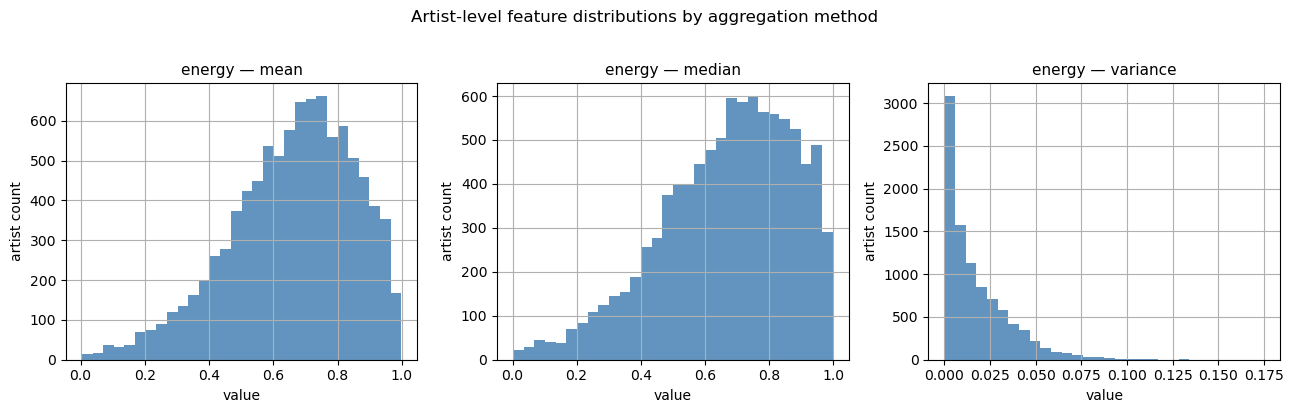


Note: variance profiles will have much smaller values and a different shape —
they describe spread within an artist's discography, not the feature value itself.


In [8]:
# visualize the three aggregation methods for one feature across all artists
feat = "energy"
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, (label, df) in zip(axes, [("mean", profiles_mean), ("median", profiles_median), ("variance", profiles_var)]):
    df[feat].hist(bins=30, ax=ax, color="steelblue", edgecolor="none", alpha=0.85)
    ax.set_title(f"{feat} — {label}", fontsize=11)
    ax.set_xlabel("value")
    ax.set_ylabel("artist count")

fig.suptitle("Artist-level feature distributions by aggregation method", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("\nNote: variance profiles will have much smaller values and a different shape —")
print("they describe spread within an artist's discography, not the feature value itself.")

## PI.5: Feature Selection — Which Features Are Most Discriminative?

Not all MIR features separate artists equally well. We measure discriminability two ways:

1. **ANOVA F-statistic** — for each feature, test whether between-artist variance is significantly larger than within-artist variance. Higher F = feature better separates artists.

2. **Mutual Information** — measures non-linear dependence between each feature and the artist label. Less assumption-heavy than ANOVA.

Both are computed on the raw per-song data. The results inform which features to weight most heavily in distance queries.

In [9]:
# encode artist_id as integer labels for sklearn
le = LabelEncoder()
artist_labels = le.fit_transform(songs["artist_id"])

X = songs[MIR_FEATURES].to_numpy(dtype=float)

# --- ANOVA F-statistic ---
# group per-feature values by artist and run one-way ANOVA
f_scores = {}
for i, feat in enumerate(MIR_FEATURES):
    groups = [X[artist_labels == label, i] for label in np.unique(artist_labels)]
    # only include groups with at least 2 samples
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        f_scores[feat] = 0.0
        continue
    f_stat, _ = f_oneway(*groups)
    f_scores[feat] = float(f_stat) if np.isfinite(f_stat) else 0.0

# --- Mutual Information ---
mi_scores = mutual_info_classif(X, artist_labels, discrete_features=False, random_state=42)

# combine into a summary DataFrame
selection_df = pd.DataFrame({
    "feature":          MIR_FEATURES,
    "anova_f":          [f_scores[f] for f in MIR_FEATURES],
    "mutual_info":      mi_scores,
})

# normalized ranks (1 = most discriminative for each metric)
selection_df["anova_rank"] = selection_df["anova_f"].rank(ascending=False).astype(int)
selection_df["mi_rank"]    = selection_df["mutual_info"].rank(ascending=False).astype(int)

selection_df = selection_df.sort_values("anova_f", ascending=False).reset_index(drop=True)

print("Feature Discriminability (sorted by ANOVA F-score):")
display(selection_df.round(3))

Feature Discriminability (sorted by ANOVA F-score):


,feature,anova_f,mutual_info,anova_rank,mi_rank
0,energy,12.537,0.571,1,2
1,danceability,11.946,0.510,2,3
2,valence,7.838,0.386,3,4
3,mode,2.233,0.573,4,1
4,tempo,2.010,0.304,5,5
5,key,1.226,0.181,6,6


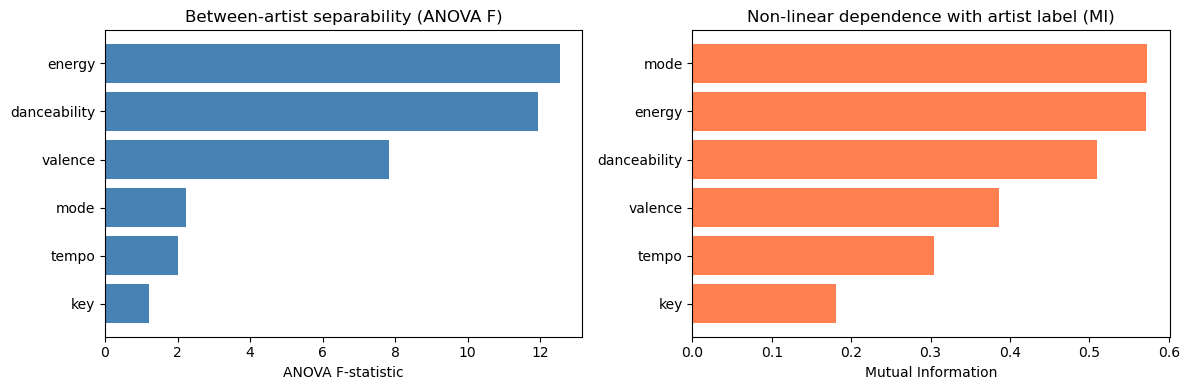

In [10]:
# visualize both metrics side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ANOVA F-score
axes[0].barh(
    selection_df["feature"],
    selection_df["anova_f"],
    color="steelblue", edgecolor="none"
)
axes[0].set_xlabel("ANOVA F-statistic")
axes[0].set_title("Between-artist separability (ANOVA F)")
axes[0].invert_yaxis()

# Mutual Information
mi_order = selection_df.sort_values("mutual_info", ascending=False)
axes[1].barh(
    mi_order["feature"],
    mi_order["mutual_info"],
    color="coral", edgecolor="none"
)
axes[1].set_xlabel("Mutual Information")
axes[1].set_title("Non-linear dependence with artist label (MI)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
# derive suggested default weights from normalized ANOVA F-scores
# (sum = 1, higher F → higher weight)
f_vals = np.array([f_scores[f] for f in MIR_FEATURES], dtype=float)
f_vals = np.where(f_vals < 0, 0.0, f_vals)  # clamp any negatives
total  = f_vals.sum()

if total > 0:
    suggested_weights = dict(zip(MIR_FEATURES, (f_vals / total).round(4)))
else:
    suggested_weights = {f: round(1 / len(MIR_FEATURES), 4) for f in MIR_FEATURES}

print("Suggested default feature weights (normalized ANOVA F-scores, sum = 1.0):")
for feat, w in sorted(suggested_weights.items(), key=lambda x: -x[1]):
    bar = "█" * int(w * 40)
    print(f"  {feat:<14} {w:.4f}  {bar}")

print("\nThese can be passed directly to Kevin's SimilarityEngine / ArtistKNNClassifier as the `weights` dict.")
print("Users can still override them manually for queries like 'similar in energy but not valence'.")

Suggested default feature weights (normalized ANOVA F-scores, sum = 1.0):
  energy         0.3318  █████████████
  danceability   0.3161  ████████████
  valence        0.2074  ████████
  mode           0.0591  ██
  tempo          0.0532  ██
  key            0.0324  █

These can be passed directly to Kevin's SimilarityEngine / ArtistKNNClassifier as the `weights` dict.
Users can still override them manually for queries like 'similar in energy but not valence'.


In [12]:
from IPython.display import display, Markdown, Math
import pandas as pd

# Example chune
example_idx = 1
example_song = songs.loc[example_idx, MIR_FEATURES].to_numpy(dtype=float)


example_norm = apply_normalization(example_song, norm_params_minmax)

# Build a simple before/after table
table_df = pd.DataFrame(
    [example_song, example_norm],
    index=["Raw", "Normalized"],
    columns=MIR_FEATURES
).round(2)

# Display outpit
display(Markdown("### Example song: raw vs. normalized"))
display(table_df)

#Formula
display(Math(r"x' = \frac{x - \min}{\max - \min}"))

display(Markdown(
    "The min and max values are saved in `norm_params_minmax`, "
    "so the same transformation can be applied to any new song at query time."
))

### Example song: raw vs. normalized

,tempo,energy,valence,danceability,key,mode
Raw,172.21,0.51,0.26,0.59,7.00,0.0
Normalized,0.66,0.51,0.26,0.57,0.64,0.0


<IPython.core.display.Math object>

The min and max values are saved in `norm_params_minmax`, so the same transformation can be applied to any new song at query time.

In [13]:
print(f"Min Danceability: {songs['danceability'].min()}")
print(f"Max Danceability: {songs['danceability'].max()}")

Min Danceability: 0.0555
Max Danceability: 0.988
